<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 106 · Distance Metrics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Distance Metrics</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The rulers behind nearest neighbors, clustering, and vector search, computed with scipy: Euclidean, Manhattan, Minkowski, cosine, Jaccard, Hamming, and Mahalanobis, why standardizing matters, and how the choice of metric changes which points count as close.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Distance Metrics: how algorithms decide what is 'close'
Nearest neighbors, clustering, recommendation, and vector search all rest on one question, **how far apart are two points?**, and the answer depends on the ruler. This notebook computes each metric with `scipy.spatial.distance`: Euclidean, Manhattan, Minkowski, cosine, Jaccard, Hamming, and Mahalanobis, shows why **scaling** changes everything, and finds a product's nearest neighbor three different ways.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from scipy.spatial.distance import euclidean, cityblock, minkowski, cosine, jaccard, hamming, mahalanobis, cdist
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', 30)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 1 &#183; THE NUMERIC RULERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Euclidean, Manhattan, Minkowski</div>
<div style="color:#4a5578;margin-top:6px">Straight-line vs city-block distance, and the family that contains both.</div>
</div>

Euclidean  (L2, straight line)  = 5.00
Manhattan  (L1, city block)     = 7.00
Minkowski p=2  = 5.00   (equals Euclidean)
Minkowski p=1  = 7.00   (equals Manhattan)


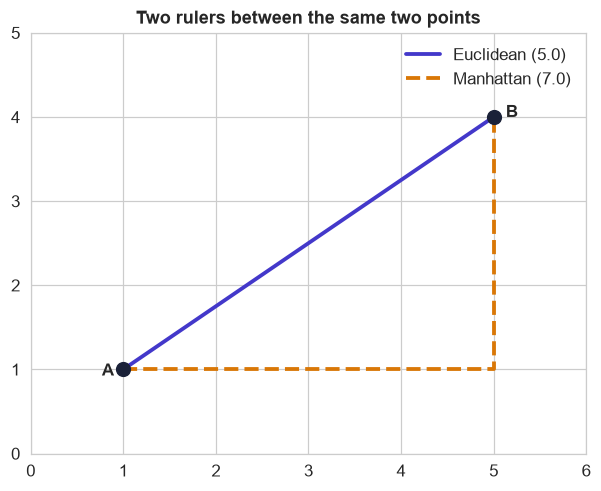

In [3]:
A, B = np.array([1, 1]), np.array([5, 4])
print(f'Euclidean  (L2, straight line)  = {euclidean(A, B):.2f}')
print(f'Manhattan  (L1, city block)     = {cityblock(A, B):.2f}')
print(f'Minkowski p=2  = {minkowski(A, B, 2):.2f}   (equals Euclidean)')
print(f'Minkowski p=1  = {minkowski(A, B, 1):.2f}   (equals Manhattan)')
fig, ax = plt.subplots(figsize=(5.6,4.6))
ax.plot([A[0],B[0]],[A[1],B[1]], color=EM, lw=2.5, label='Euclidean (5.0)')
ax.plot([A[0],B[0],B[0]],[A[1],A[1],B[1]], color=AMBER, lw=2.5, ls='--', label='Manhattan (7.0)')
ax.scatter(*A, s=80, color=INK, zorder=3); ax.scatter(*B, s=80, color=INK, zorder=3)
ax.annotate('A', A, textcoords='offset points', xytext=(-14,-4), fontweight='bold')
ax.annotate('B', B, textcoords='offset points', xytext=(8,0), fontweight='bold')
ax.set(title='Two rulers between the same two points', xlim=(0,6), ylim=(0,5)); ax.legend()
plt.tight_layout(); plt.show()

**What the code shows.** **Euclidean** distance is the straight line (the length of the green segment). **Manhattan** distance walks along the axes like a taxi on a grid, so it is longer (4 across + 3 up = 7). **Minkowski** is the general form with a parameter p: **p = 2 gives Euclidean, p = 1 gives Manhattan**, and larger p weights the biggest coordinate difference more heavily. Euclidean is the default, but Manhattan is more robust to outliers and natural for grid-like or high-dimensional data.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; WHY YOU MUST SCALE FIRST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Distance is dominated by the biggest-scale feature</div>
<div style="color:#4a5578;margin-top:6px">Standardize, or price drowns out rating.</div>
</div>

distances from P1 (a cheap, low-rated item):
    raw_distance  scaled_distance
P1          0.00             0.00
P2         10.18             2.18
P3        200.00             2.18

RAW  -> nearest to P1 is P2 (picked by price alone)
SCALED -> nearest to P1 is P3 (price and rating count equally)


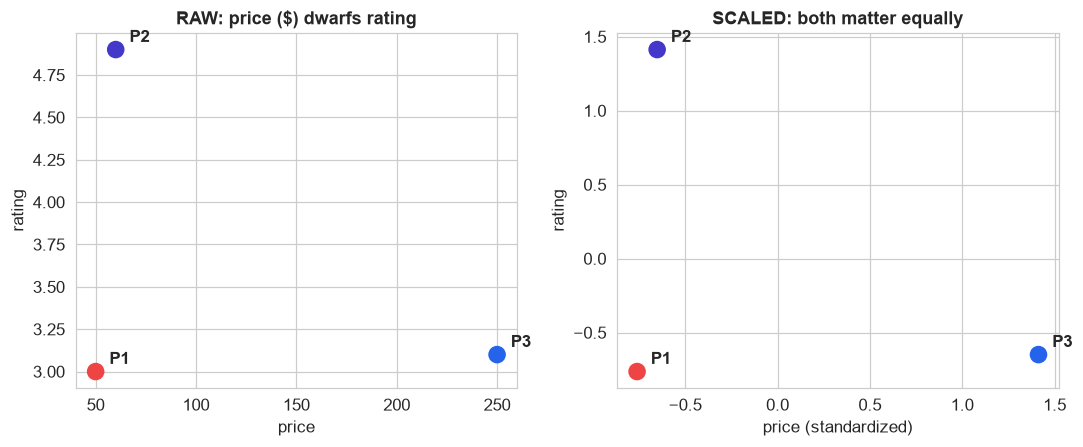

In [4]:
two = pd.DataFrame({'price':[50, 60, 250], 'rating':[3.0, 4.9, 3.1]}, index=['P1','P2','P3'])
raw = cdist(two.iloc[[0]], two, 'euclidean')[0]
std = cdist(StandardScaler().fit_transform(two)[[0]], StandardScaler().fit_transform(two), 'euclidean')[0]
print('distances from P1 (a cheap, low-rated item):')
print(pd.DataFrame({'raw_distance': raw.round(2), 'scaled_distance': std.round(2)}, index=two.index))
print('\nRAW  -> nearest to P1 is', two.index[np.argsort(raw)[1]], '(picked by price alone)')
print('SCALED -> nearest to P1 is', two.index[np.argsort(std)[1]], '(price and rating count equally)')
Z = StandardScaler().fit_transform(two)
fig, ax = plt.subplots(1, 2, figsize=(10,4.2))
for a,(data,ttl,xl) in zip(ax, [(two.values,'RAW: price ($) dwarfs rating','price'),(Z,'SCALED: both matter equally','price (standardized)')]):
    a.scatter(data[:,0], data[:,1], s=110, color=[RED,EM,BLUE], zorder=3)
    for i,name in enumerate(two.index): a.annotate(name, (data[i,0],data[i,1]), textcoords='offset points', xytext=(9,5), fontweight='bold')
    a.set(title=ttl, xlabel=xl, ylabel='rating')
plt.tight_layout(); plt.show()

**The trap.** Price ranges in the hundreds while rating ranges 0 to 5, so **raw Euclidean distance is almost entirely price**: P1 looks closest to P2 only because their prices are similar, ignoring that their ratings differ by 1.9 stars. After `StandardScaler` puts both features on the same footing (mean 0, standard deviation 1), the nearest neighbor can change. **Always standardize numeric features before any distance-based method**, this one line fixes the most common mistake in KNN and clustering.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; COSINE SIMILARITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Direction, not magnitude</div>
<div style="color:#4a5578;margin-top:6px">Two vectors pointing the same way are 'similar' even at different lengths.</div>
</div>

cosine similarity u,v = 1.000   (same direction, different length)
cosine similarity u,w = 0.614   (different direction)
Euclidean u,v = 4.47  <- large, even though direction is identical


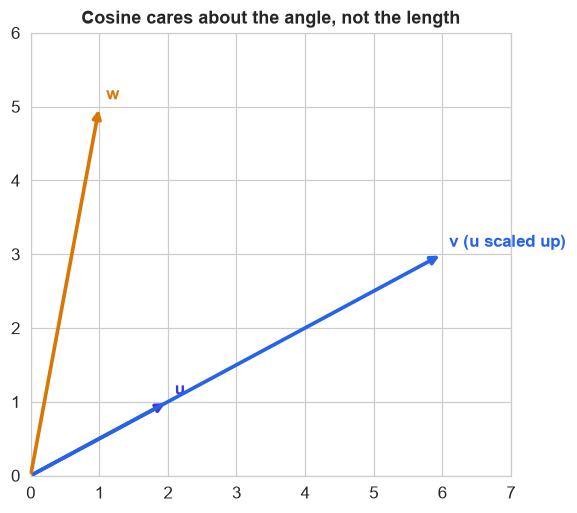

In [5]:
u = np.array([2, 1]); v = np.array([6, 3]); w = np.array([1, 5])
print(f'cosine similarity u,v = {1-cosine(u,v):.3f}   (same direction, different length)')
print(f'cosine similarity u,w = {1-cosine(u,w):.3f}   (different direction)')
print(f'Euclidean u,v = {euclidean(u,v):.2f}  <- large, even though direction is identical')
fig, ax = plt.subplots(figsize=(5.4,4.8))
for vec,c,lab in [(u,EM,'u'),(v,BLUE,'v (u scaled up)'),(w,AMBER,'w')]:
    ax.annotate('', xy=vec, xytext=(0,0), arrowprops=dict(arrowstyle='-|>', color=c, lw=2.4))
    ax.text(vec[0]+0.1, vec[1]+0.1, lab, color=c, fontweight='bold')
ax.set(title='Cosine cares about the angle, not the length', xlim=(0,7), ylim=(0,6)); plt.tight_layout(); plt.show()

**What the code shows.** `u` and `v` point in exactly the same direction (v is u tripled), so their **cosine similarity is 1.0** even though their Euclidean distance is large. `w` points elsewhere, so its cosine similarity is lower. Cosine ignores magnitude and measures only the **angle** between vectors, which is why it is the default for text (a long and a short document about the same topic should count as similar) and for the embedding vectors behind modern search.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; JACCARD &amp; HAMMING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Distances for sets and binary strings</div>
<div style="color:#4a5578;margin-top:6px">When features are yes/no flags, count overlaps and mismatches.</div>
</div>

product 1 flags: [1 1 0 1 0]   product 2 flags: [1 0 0 1 1]
Jaccard similarity = 0.500   (shared features / features either has)
Hamming distance   = 2 of 5 flags differ


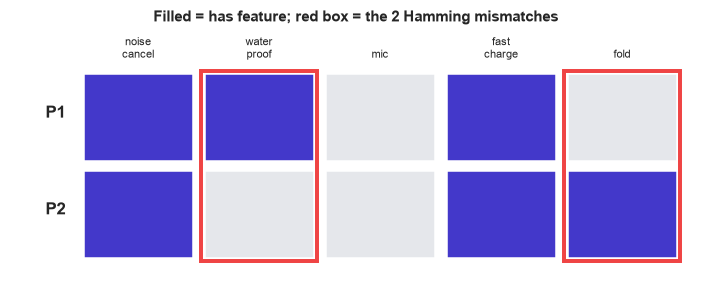

In [6]:
p1 = np.array([1,1,0,1,0], dtype=bool)   # noise_cancel, waterproof, mic, fast_charge, foldable
p2 = np.array([1,0,0,1,1], dtype=bool)
print('product 1 flags:', p1.astype(int), '  product 2 flags:', p2.astype(int))
print(f'Jaccard similarity = {1-jaccard(p1,p2):.3f}   (shared features / features either has)')
print(f'Hamming distance   = {int(hamming(p1,p2)*len(p1))} of {len(p1)} flags differ')
labels = ['noise\ncancel','water\nproof','mic','fast\ncharge','fold']
fig, ax = plt.subplots(figsize=(6.6,2.8))
for i in range(5):
    for vec,yy in [(p1,1.05),(p2,0.05)]:
        ax.add_patch(plt.Rectangle((i,yy),0.9,0.9, color=EM if vec[i] else '#e5e7eb', ec='white'))
    if p1[i]!=p2[i]: ax.add_patch(plt.Rectangle((i-0.03,0.02),0.96,1.96, fill=False, ec=RED, lw=2.6))
    ax.text(i+0.45, 2.12, labels[i], ha='center', fontsize=7.5)
ax.text(-0.15,1.5,'P1',ha='right',fontweight='bold'); ax.text(-0.15,0.5,'P2',ha='right',fontweight='bold')
ax.set(xlim=(-0.6,5.1), ylim=(-0.2,2.4)); ax.axis('off')
ax.set_title('Filled = has feature; red box = the 2 Hamming mismatches', fontsize=10); plt.tight_layout(); plt.show()

**What the code shows.** For **binary** or **set** data the numeric rulers make little sense; instead we count. **Jaccard similarity** is the size of the intersection over the union, here the two products share 2 features (noise-cancel and fast-charge) out of 4 that at least one has, so 2/4 = 0.5. **Hamming distance** counts the positions that differ (2 of 5 flags). Jaccard suits sparse presence/absence data (tags, market baskets); Hamming suits fixed-length codes (categorical encodings, DNA, error-correcting codes).

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; MAHALANOBIS DISTANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Distance that respects correlation</div>
<div style="color:#4a5578;margin-top:6px">Euclidean treats every direction alike; Mahalanobis knows the data's shape.</div>
</div>

along the trend (3,3)   Euclidean 4.14   Mahalanobis 3.00
off the trend (3,-3)    Euclidean 4.25   Mahalanobis 13.47


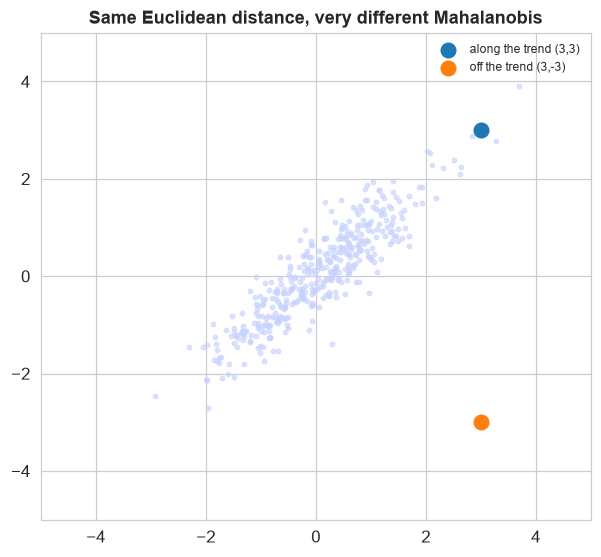

In [7]:
rng = np.random.default_rng(0)
cloud = rng.multivariate_normal([0,0], [[1,0.9],[0.9,1]], size=400)   # strongly correlated features
VI = np.linalg.inv(np.cov(cloud.T))
center = cloud.mean(axis=0)
cand = {'along the trend (3,3)': np.array([3.0,3.0]), 'off the trend (3,-3)': np.array([3.0,-3.0])}
for name,pt in cand.items():
    print(f'{name:22s}  Euclidean {euclidean(pt,center):.2f}   Mahalanobis {mahalanobis(pt,center,VI):.2f}')
fig, ax = plt.subplots(figsize=(5.6,5.2))
ax.scatter(cloud[:,0], cloud[:,1], s=8, color=LIGHT, alpha=0.6)
for name,pt in cand.items(): ax.scatter(*pt, s=90, zorder=3, label=name)
ax.set(title='Same Euclidean distance, very different Mahalanobis', xlim=(-5,5), ylim=(-5,5)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What the code shows.** Both candidate points sit at **nearly the same Euclidean distance** from the center, but one lies **along** the data's correlated trend and the other **against** it. **Mahalanobis distance** divides by the covariance (`VI` is the inverse covariance), so it stretches distances along thin directions: the off-trend point is judged **much farther**, because it is a genuine outlier relative to the data's shape. Euclidean sees a circle; Mahalanobis sees the ellipse the data actually forms, which is why it is the standard tool for multivariate outlier detection.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 6 &#183; NEAREST NEIGHBOR, THREE WAYS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The metric changes the recommendation</div>
<div style="color:#4a5578;margin-top:6px">On the real catalog, different rulers pick different 'most similar' products.</div>
</div>

In [8]:
try: df = pd.read_excel('../../data/distance-metrics--products.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'distance-metrics--products.xlsx', sheet_name='Data')
num = ['price','weight_g','battery_hrs','rating']; flags = ['noise_cancel','waterproof','has_mic','fast_charge','foldable']
q = 0   # the query product (first row)
Xs = StandardScaler().fit_transform(df[num])
d_euc = cdist(Xs[[q]], Xs, 'euclidean')[0]
d_cos = cdist(Xs[[q]], Xs, 'cosine')[0]   # cosine on the standardized spec profile (shape, not size)
d_jac = cdist(df[flags].values[[q]].astype(bool), df[flags].values.astype(bool), 'jaccard')[0]
def nearest(d): idx = np.argsort(d); return idx[idx!=q][0]
print('QUERY product:', df.loc[q,'product_id'], '|', df.loc[q,'brand_tier'], '| flags', df.loc[q,flags].tolist())
for name,d in [('Euclidean (scaled specs)',d_euc),('Cosine (spec direction)',d_cos),('Jaccard (feature flags)',d_jac)]:
    j = nearest(d); print(f'  nearest by {name:26s} -> {df.loc[j,"product_id"]} ({df.loc[j,"brand_tier"]})')

QUERY product: H300 | premium | flags [1, 1, 0, 0, 0]
  nearest by Euclidean (scaled specs)   -> H383 (premium)
  nearest by Cosine (spec direction)    -> H347 (premium)
  nearest by Jaccard (feature flags)    -> H336 (premium)


**What the code shows.** For one query headphone, all three rulers pick a **different nearest neighbor**: standardized-Euclidean matches on the size of the numeric specs (price, battery, weight, rating), **cosine** matches the direction of the standardized spec profile (the balance of specs, not their size), and **Jaccard** matches on shared yes/no features. None is universally right, the metric encodes what you mean by 'similar', and choosing it is a modeling decision. This is exactly the choice a **K-nearest-neighbors** model or a recommender makes on every query.

## Choosing a distance, in one view

- **Euclidean (L2)**: the default for continuous features, straight-line distance; always **standardize first**.
- **Manhattan (L1)**: sum of absolute differences; robust to outliers, natural in high dimensions. Both are special cases of **Minkowski** (p = 2 and p = 1).
- **Cosine**: angle between vectors, ignores magnitude; the default for text and embedding similarity.
- **Jaccard / Hamming**: for binary or set data, overlap of sets, and count of differing positions.
- **Mahalanobis**: Euclidean corrected for feature covariance; the tool for multivariate outliers.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>